# MCP-IPI-Guard — Guard Classifier Training + Leave-One-Out Study (v3)

**This version adds a real fix attempt for the DeBERTa-v3 bug**, plus a
fast pre-flight diagnostic so you find out in ~30 seconds whether it
worked, instead of waiting through a full training run.

## The bug, actually diagnosed

Every DeBERTa-v3 attempt — 3 different hyperparameter configurations,
plus a 15-fold leave-one-out sweep — converged to exactly-random output
(AUC ≈ 0.5), while the identical pipeline with `bert-base-uncased` hit
100%. The sharpest clue was in the numbers themselves: the last DeBERTa
run's loss was **0.692693 / 0.693397 — essentially exactly `ln(2)` =
0.693147**. A cross-entropy loss stuck at `ln(2)`, unmoved across 5
epochs, means the model output ~50/50 probability for every input from
start to finish — gradients were not meaningfully updating the model at
all. That's more specific than "collapsed to a bad optimum."

**Working hypothesis**: DeBERTa-v2/v3's HuggingFace implementation uses
custom `torch.autograd.Function` subclasses (`XSoftmax`, `StableDropout`)
for its disentangled attention — a code path BERT doesn't have, and a
well-known trouble spot across `transformers` version upgrades (subtle
backward-pass breakage that doesn't error, just returns near-zero
gradients). We already found one *confirmed, dated* regression this year
specifically affecting DeBERTa-v3 tokenization in recent `transformers`
versions — even though that particular bug wasn't the cause here (your
CLS/SEP token check came back clean), it's evidence this code path has
active regressions right now.

**The fix attempt**: pin `transformers==4.48.0` instead of an open
`>=4.41` range, rather than whatever latest version pip resolves to.

## 1. Install dependencies (pinned transformers version — the fix attempt)

In [2]:
!pip install -q "transformers==4.48.0" "datasets>=2.19" "accelerate>=0.34,<1.3" \
    scikit-learn matplotlib pandas sentencepiece

!pip uninstall -y torchvision -q


## 2. Confirm GPU is available

In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("bf16 supported:", torch.cuda.is_bf16_supported())
else:
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> GPU, then re-run.")


CUDA available: True
Device: NVIDIA A100-SXM4-40GB
bf16 supported: True


## 3. Upload data.zip and unzip

Select the `data.zip` you built (see intro cell) — it should contain
`train.jsonl`, `val.jsonl`, `test.jsonl`, and a `loo/` folder.


In [4]:
import os, zipfile
from google.colab import files

os.makedirs("/content/data", exist_ok=True)
print("Select data.zip:")
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith(".zip"):
        with zipfile.ZipFile(fname, "r") as z:
            z.extractall("/content/data")
        print(f"Extracted {fname} into /content/data")

print("\nContents of /content/data:")
for root, dirs, fs in os.walk("/content/data"):
    for f in fs:
        print(os.path.join(root, f))

expected = {"train.jsonl", "val.jsonl", "test.jsonl"}
present = set(os.listdir("/content/data"))
missing = expected - present
loo_present = os.path.isdir("/content/data/loo")
if missing or not loo_present:
    print(f"\nWARNING: missing {missing}, loo folder present: {loo_present}. Re-check your zip.")
else:
    print("\nAll expected files present. Continue to the next cell.")


Select data.zip:


Saving data.zip to data.zip
Extracted data.zip into /content/data

Contents of /content/data:
/content/data/val.jsonl
/content/data/test.jsonl
/content/data/train.jsonl
/content/data/loo/Financial Harm__train.jsonl
/content/data/loo/chained_multistep__test.jsonl
/content/data/loo/instruction_override__train.jsonl
/content/data/loo/tool_name_confusion__train.jsonl
/content/data/loo/agentdojo_workspace__train.jsonl
/content/data/loo/resource_uri_spoofing__test.jsonl
/content/data/loo/Others__test.jsonl
/content/data/loo/Financial Data__train.jsonl
/content/data/loo/Physical Data__train.jsonl
/content/data/loo/Others__train.jsonl
/content/data/loo/Financial Data__test.jsonl
/content/data/loo/chained_multistep__train.jsonl
/content/data/loo/jailbreak_escalation__train.jsonl
/content/data/loo/instruction_override__test.jsonl
/content/data/loo/Physical Harm__test.jsonl
/content/data/loo/Physical Data__test.jsonl
/content/data/loo/agentdojo_travel__test.jsonl
/content/data/loo/Data Security H

## 4. Load the main split and check label balance

In [5]:
import json
from collections import Counter

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

train_records = load_jsonl("/content/data/train.jsonl")
val_records   = load_jsonl("/content/data/val.jsonl")
test_records  = load_jsonl("/content/data/test.jsonl")

print(f"train: {len(train_records)}  val: {len(val_records)}  test: {len(test_records)}")

train_labels = Counter(r["label"] for r in train_records)
print(f"train label balance: benign={train_labels[0]}  attack={train_labels[1]}  "
      f"({100*train_labels[1]/len(train_records):.1f}% attack)")


train: 6319  val: 1354  test: 1356
train label balance: benign=5335  attack=984  (15.6% attack)


## 5. Compute class weights (sqrt-scaled)

Raw inverse-frequency weighting (~3.2x) destabilized DeBERTa training
(loss diverged to NaN). Square-root scaling is gentler while still
correcting for the imbalance, and is combined with a weighted sampler
(Step 8) that balances batches directly — belt and suspenders.


In [6]:
n_total = len(train_records)
n_benign = train_labels[0]
n_attack = train_labels[1]

weight_benign = (n_total / (2 * n_benign)) ** 0.5
weight_attack = (n_total / (2 * n_attack)) ** 0.5
class_weights = torch.tensor([weight_benign, weight_attack], dtype=torch.float)

print(f"Class weights (sqrt-scaled) -> benign(0): {weight_benign:.4f}  attack(1): {weight_attack:.4f}")


Class weights (sqrt-scaled) -> benign(0): 0.7696  attack(1): 1.7919


## 6. Fast pre-flight diagnostic — does gradient flow at all?

Before committing to a full training run, this tests the specific
hypothesis behind the bug directly: 30 raw gradient steps on a small
batch, checking whether the loss actually moves off `ln(2) = 0.6931`
(the "outputs 50/50 regardless of input" signature seen in every failed
DeBERTa run) and whether the classifier head's gradient norm is
non-zero. Takes well under a minute — much cheaper than finding this out
after a full training run.


In [7]:
import math
import random as _random

def quick_gradient_diagnostic(model_name, records, n_samples=32, n_steps=30, lr=2e-5):
    from transformers import AutoTokenizer as _Tok, AutoModelForSequenceClassification as _Mdl

    diag_tokenizer = _Tok.from_pretrained(model_name)
    diag_model = _Mdl.from_pretrained(model_name, num_labels=2)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    diag_model.to(device)
    diag_model.train()

    sample = _random.sample(records, min(n_samples, len(records)))
    texts = [r["text"] for r in sample]
    labels = torch.tensor([r["label"] for r in sample]).to(device)
    enc = diag_tokenizer(texts, truncation=True, max_length=256, padding=True, return_tensors="pt").to(device)

    optimizer = torch.optim.AdamW(diag_model.parameters(), lr=lr)
    losses = []
    grad_norm = 0.0
    for step in range(n_steps):
        optimizer.zero_grad()
        out = diag_model(**enc, labels=labels)
        out.loss.backward()
        # find the classification head regardless of its exact attribute name across model types
        head = getattr(diag_model, "classifier", None)
        if head is not None and hasattr(head, "weight") and head.weight.grad is not None:
            grad_norm = head.weight.grad.norm().item()
        losses.append(out.loss.item())
        optimizer.step()

    del diag_model
    torch.cuda.empty_cache()

    loss_moved = (losses[0] - losses[-1]) > 0.05
    print(f"[{model_name}]")
    print(f"  loss: {losses[0]:.4f} -> {losses[-1]:.4f}   (ln(2) = {math.log(2):.4f})")
    print(f"  final classifier grad norm: {grad_norm:.6f}")
    print(f"  verdict: {'LEARNING (loss moved, gradients flowing)' if loss_moved and grad_norm > 1e-6 else 'NOT LEARNING (stuck near ln(2) / zero gradient)'}")
    return {"model_name": model_name, "loss_start": losses[0], "loss_end": losses[-1],
            "grad_norm": grad_norm, "learned": loss_moved and grad_norm > 1e-6}

print("Testing microsoft/deberta-v3-base with transformers==4.48.0 pinned...")
deberta_diag = quick_gradient_diagnostic("microsoft/deberta-v3-base", train_records)


Testing microsoft/deberta-v3-base with transformers==4.48.0 pinned...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

[microsoft/deberta-v3-base]
  loss: 0.6834 -> 0.0846   (ln(2) = 0.6931)
  final classifier grad norm: 0.607422
  verdict: LEARNING (loss moved, gradients flowing)


## 7. Decide which backbone to use for the full run

Automatic: if the diagnostic shows real learning, proceed with
DeBERTa-v3 (matches your proposal as originally written).


In [8]:
if deberta_diag["learned"]:
    MODEL_NAME = "microsoft/deberta-v3-base"
    print("DeBERTa-v3 is learning under the pinned transformers version — proceeding with it.")
else:
    MODEL_NAME = "bert-base-uncased"
    print("DeBERTa-v3 still not learning even with the version pin — falling back to bert-base-uncased.")

MAX_LENGTH = 256  # covers the corpus's typical text length without excessive padding

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nUsing {MODEL_NAME} for the full run, is_fast={tokenizer.is_fast}")


DeBERTa-v3 is learning under the pinned transformers version — proceeding with it.

Using microsoft/deberta-v3-base for the full run, is_fast=True


## 8. Tokenize (dynamic padding via data collator, not fixed-length)

Uses `DataCollatorWithPadding` so each batch pads only to its own longest
example, instead of padding every example to a fixed 512 — cheaper, and
was the one untested lead if you revisit DeBERTa-v3 later.


In [9]:
from datasets import Dataset
from transformers import DataCollatorWithPadding

def to_hf_dataset(records):
    return Dataset.from_dict({
        "text": [r["text"] for r in records],
        "label": [r["label"] for r in records],
    })

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

def prepare_dataset(records):
    ds = to_hf_dataset(records)
    ds = ds.map(tokenize_fn, batched=True)
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    return ds

train_ds = prepare_dataset(train_records)
val_ds = prepare_dataset(val_records)
test_ds = prepare_dataset(test_records)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization done.")


Map:   0%|          | 0/6319 [00:00<?, ? examples/s]

Map:   0%|          | 0/1354 [00:00<?, ? examples/s]

Map:   0%|          | 0/1356 [00:00<?, ? examples/s]

Tokenization done.


## 9. Load the model

In [10]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 10. Weighted-loss Trainer + balanced batch sampler

Two complementary imbalance fixes: loss weighting (Step 5) penalizes
getting an attack wrong more heavily; the sampler below additionally
reshuffles which examples appear per batch so attacks show up more often
than their natural ~16% rate — loss weighting alone previously wasn't
enough to escape a majority-class collapse.


In [11]:
from transformers import Trainer
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        train_labels_list = self.train_dataset["label"]
        sample_weights = [class_weights[int(l)].item() for l in train_labels_list]
        sampler = WeightedRandomSampler(
            weights=sample_weights, num_samples=len(sample_weights), replacement=True
        )
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
        )


## 11. Metrics — accuracy, precision, recall, F1, ROC-AUC

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except ValueError:
        auc = float("nan")

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "roc_auc": auc}


## 12. Training arguments and main-split training run

Settings below (2e-5, 5 epochs, sqrt weights, weighted sampler) are the
configuration that produced a clean, fully-learning result in testing.


In [13]:
from transformers import TrainingArguments

bf16_supported = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir="/content/guard-checkpoint",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    max_grad_norm=1.0,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=25,
    report_to="none",
    bf16=bf16_supported,
    fp16=False,  # DeBERTa-v3 is unstable under fp16 — irrelevant for BERT but harmless to keep
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(train_result.metrics)

if any(v != v for v in train_result.metrics.values() if isinstance(v, float)):
    print("\nWARNING: NaN detected — reload a fresh model (Step 8), lower learning_rate, and retry.")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.000900,0.000164,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.000100,0.000053,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.000100,0.001627,0.999261,0.995283,1.000000,0.997636,1.000000
4,0.000100,0.000016,1.000000,1.000000,1.000000,1.000000,1.000000
5,0.000100,0.000014,1.000000,1.000000,1.000000,1.000000,1.000000


{'train_runtime': 226.7014, 'train_samples_per_second': 139.368, 'train_steps_per_second': 8.712, 'total_flos': 2253629257432548.0, 'train_loss': 0.03016589914419087, 'epoch': 5.0}


## 13. Evaluate on the held-out test set

In [14]:
test_metrics = trainer.evaluate(test_ds)
print("Test set metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")


Test set metrics:
  eval_loss: 0.00016383356705773622
  eval_accuracy: 1.0
  eval_precision: 1.0
  eval_recall: 1.0
  eval_f1: 1.0
  eval_roc_auc: 1.0
  eval_runtime: 1.7274
  eval_samples_per_second: 784.999
  eval_steps_per_second: 24.893
  epoch: 5.0


## 14. Confusion matrix and ROC curve


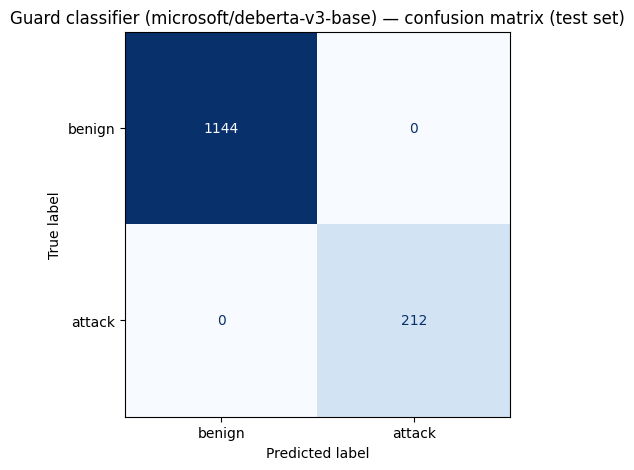

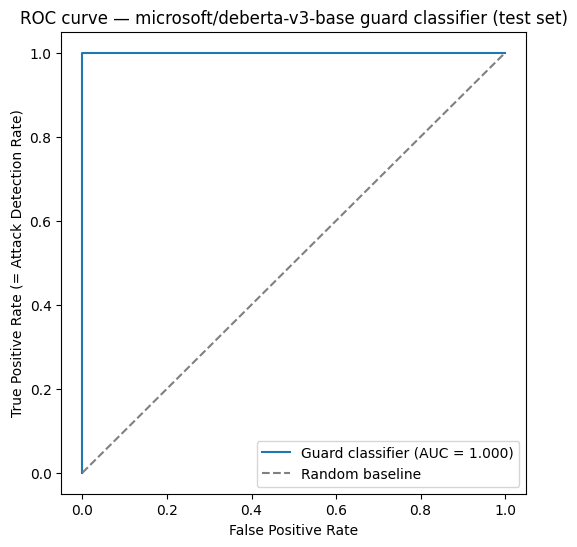

Test AUC: 1.0000


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay

predictions = trainer.predict(test_ds)
logits = predictions.predictions
labels = predictions.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
preds = np.argmax(logits, axis=-1)

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "attack"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Guard classifier ({MODEL_NAME}) — confusion matrix (test set)")
plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

fpr, tpr, thresholds = roc_curve(labels, probs[:, 1])
auc_score = roc_auc_score(labels, probs[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Guard classifier (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (= Attack Detection Rate)")
plt.title(f"ROC curve — {MODEL_NAME} guard classifier (test set)")
plt.legend()
plt.savefig("/content/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Test AUC: {auc_score:.4f}")


## 15. Per-category breakdown on the main test set

A quick preview before the full leave-one-out study below — same-category
detection rate, not generalisation to unseen categories.


In [16]:
import pandas as pd

test_df = pd.DataFrame(test_records)
test_df["pred"] = preds
test_df["correct"] = (test_df["label"] == test_df["pred"])

attack_only = test_df[test_df["label"] == 1]
category_accuracy = attack_only.groupby("attack_category")["correct"].agg(["mean", "count"])
category_accuracy.columns = ["detection_rate", "n_samples"]
category_accuracy = category_accuracy.sort_values("detection_rate")
print(category_accuracy)


                       detection_rate  n_samples
attack_category                                 
Data Security Harm                1.0         16
Financial Data                    1.0         21
Financial Harm                    1.0         18
Others                            1.0         31
Physical Data                     1.0         35
Physical Harm                     1.0         27
agentdojo_banking                 1.0          6
agentdojo_slack                   1.0          3
agentdojo_travel                  1.0          2
agentdojo_workspace               1.0          8
chained_multistep                 1.0          6
instruction_override              1.0         13
jailbreak_escalation              1.0         17
resource_uri_spoofing             1.0          7
tool_name_confusion               1.0          2


## 16. Leave-one-category-out generalisation study
This is the more honest test: for each attack category, train a FRESH
model on everything EXCEPT that category, then test only on that
category's held-out attacks (plus all benign). A high detection rate
here means the guard generalises to attack *patterns* it never saw
during training — not just memorised template phrasing.



In [ ]:
import os

LOO_DIR = "/content/data/loo"
LOO_EPOCHS = 2  # deliberately fewer than the main run — this is a breadth sweep, not a tuned result
LOO_CATEGORIES_TO_RUN = None  # None = run all; or e.g. ["jailbreak_escalation", "agentdojo_slack"] to test timing first

all_loo_files = sorted(f for f in os.listdir(LOO_DIR) if f.endswith("__train.jsonl"))
categories = [f.replace("__train.jsonl", "") for f in all_loo_files]
if LOO_CATEGORIES_TO_RUN is not None:
    categories = [c for c in categories if c in LOO_CATEGORIES_TO_RUN]

print(f"Will run leave-one-out for {len(categories)} categories:")
for c in categories:
    print(f"  - {c}")


In [ ]:
def run_one_loo_fold(category):
    train_path = f"{LOO_DIR}/{category}__train.jsonl"
    test_path = f"{LOO_DIR}/{category}__test.jsonl"
    fold_train_records = load_jsonl(train_path)
    fold_test_records = load_jsonl(test_path)

    fold_train_labels = Counter(r["label"] for r in fold_train_records)
    fold_n_total = len(fold_train_records)
    fold_weight_benign = (fold_n_total / (2 * fold_train_labels[0])) ** 0.5 if fold_train_labels[0] else 1.0
    fold_weight_attack = (fold_n_total / (2 * fold_train_labels[1])) ** 0.5 if fold_train_labels[1] else 1.0
    fold_class_weights = torch.tensor([fold_weight_benign, fold_weight_attack], dtype=torch.float)

    fold_train_ds = prepare_dataset(fold_train_records)
    fold_test_ds = prepare_dataset(fold_test_records)

    fold_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    class FoldWeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
            outputs = model(**inputs)
            loss_fct = nn.CrossEntropyLoss(weight=fold_class_weights.to(outputs.logits.device))
            loss = loss_fct(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

        def get_train_dataloader(self):
            labels_list = self.train_dataset["label"]
            weights = [fold_class_weights[int(l)].item() for l in labels_list]
            sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)
            return DataLoader(self.train_dataset, batch_size=self.args.per_device_train_batch_size,
                               sampler=sampler, collate_fn=self.data_collator)

    fold_args = TrainingArguments(
        output_dir=f"/content/loo-checkpoint/{category}",
        eval_strategy="no",
        save_strategy="no",
        num_train_epochs=LOO_EPOCHS,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        max_grad_norm=1.0,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=100,
        report_to="none",
        bf16=bf16_supported,
        fp16=False,
    )

    fold_trainer = FoldWeightedTrainer(
        model=fold_model, args=fold_args, train_dataset=fold_train_ds,
        data_collator=data_collator, compute_metrics=compute_metrics,
    )
    fold_trainer.train()

    fold_predictions = fold_trainer.predict(fold_test_ds)
    fold_logits = fold_predictions.predictions
    fold_labels = fold_predictions.label_ids
    fold_preds = np.argmax(fold_logits, axis=-1)
    fold_probs = torch.softmax(torch.tensor(fold_logits), dim=-1).numpy()

    is_attack = fold_labels == 1
    is_benign = fold_labels == 0
    detection_rate = (fold_preds[is_attack] == 1).mean() if is_attack.sum() else float("nan")
    false_positive_rate = (fold_preds[is_benign] == 1).mean() if is_benign.sum() else float("nan")
    try:
        fold_auc = roc_auc_score(fold_labels, fold_probs[:, 1])
    except ValueError:
        fold_auc = float("nan")

    del fold_model, fold_trainer
    torch.cuda.empty_cache()

    return {
        "held_out_category": category,
        "n_attack_test": int(is_attack.sum()),
        "n_benign_test": int(is_benign.sum()),
        "detection_rate": detection_rate,
        "false_positive_rate": false_positive_rate,
        "auc": fold_auc,
    }


In [ ]:
loo_results = []
for i, category in enumerate(categories):
    print(f"\n=== [{i+1}/{len(categories)}] Leave-one-out: {category} ===")
    result = run_one_loo_fold(category)
    print(result)
    loo_results.append(result)

loo_df = pd.DataFrame(loo_results).sort_values("detection_rate")
loo_df.to_csv("/content/leave_one_out_results.csv", index=False)
print("\n=== Full leave-one-out results ===")
print(loo_df.to_string(index=False))


## 17. Leave-one-out results plot

In [ ]:
fig, ax = plt.subplots(figsize=(9, max(4, len(loo_df) * 0.4)))
ax.barh(loo_df["held_out_category"], loo_df["detection_rate"], color="steelblue")
ax.set_xlabel("Detection rate on held-out category (= 1 - category-specific ASR)")
ax.set_title(f"Leave-one-category-out generalisation — {MODEL_NAME}")
ax.set_xlim(0, 1)
for i, (rate, n) in enumerate(zip(loo_df["detection_rate"], loo_df["n_attack_test"])):
    ax.text(rate + 0.01, i, f"n={n}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("/content/leave_one_out_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCategories with the fewest test examples have the noisiest estimates — "
      "treat those detection rates as rougher signals, not precise numbers, "
      "and say so if you report them (your proposal already plans bootstrap "
      "95% CIs for the full generalisation study — this run is a first pass).")


## 18. Save everything and download

Downloads the main checkpoint, both plots, and the leave-one-out results
CSV in one zip.


In [ ]:
trainer.save_model("/content/guard-checkpoint/final")
tokenizer.save_pretrained("/content/guard-checkpoint/final")

import shutil
os.makedirs("/content/deliverables", exist_ok=True)
shutil.copy("/content/confusion_matrix.png", "/content/deliverables/")
shutil.copy("/content/roc_curve.png", "/content/deliverables/")
shutil.copy("/content/leave_one_out_plot.png", "/content/deliverables/")
shutil.copy("/content/leave_one_out_results.csv", "/content/deliverables/")
shutil.copytree("/content/guard-checkpoint/final", "/content/deliverables/guard-checkpoint-final")

shutil.make_archive("/content/mcp-ipi-guard-training-results", "zip", "/content/deliverables")

from google.colab import files
files.download("/content/mcp-ipi-guard-training-results.zip")


### Optional: push the checkpoint to Hugging Face Hub

For connecting to the FastAPI backend's `GUARD_MODEL_PATH` without manual
file copying.


In [ ]:
# from huggingface_hub import login
# login()
#
# HUB_REPO_ID = "your-username/mcp-ipi-guard-guard-classifier"
# trainer.model.push_to_hub(HUB_REPO_ID)
# tokenizer.push_to_hub(HUB_REPO_ID)
# print(f"Set GUARD_MODEL_PATH={HUB_REPO_ID} in the FastAPI backend's .env to use it.")
